In [1]:
# ============================================================================
# CELL 0: Install Library (If using VSCode)
# ============================================================================

# 1. Masuk Terminal
# 2. Buat .venv
    # python -m venv .venv
# 3. Aktifkan
    # .venv\Scripts\activate        # Windows
    # source .venv/bin/activate     # Mac/Linux
# 4. Install library
    # pip install -r requirements.txt
# 5. Run kode

In [2]:
# ============================================================================
# CELL 1: Initiate Kaggle Default libraries. (DO NOT TOUCH)
# ============================================================================

# Before so... you have to input link of the dataset first in the right panel of the screen
# To do that... go to "+ Add Input" > Type the input/dataset/notebooks which contains the dataset you want to train
# For this case, the dataset we need is a "work-from-home-employee-burnout-dataset" by Sonal Shinde

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Matikan peringatan yang tidak perlu agar notebook terlihat rapi
import warnings
warnings.filterwarnings('ignore')

# Cek lokasi file dataset dari Kaggle Input (Khusus lewat Kaggle)
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)
        print("Dataset ditemukan di:", file_path)

Dataset ditemukan di: /kaggle/input/datasets/sonalshinde123/work-from-home-employee-burnout-dataset/work_from_home_burnout_dataset.csv


In [3]:
# ============================================================================
# CELL 2: Load Data & Pre-EDA (Exploratory Data Analysis) Data Cleaning
# ============================================================================

# PERHATIAN: Ganti string di bawah ini dengan path file CSV-mu yang muncul dari print di atas atau input manual
DATASET_PATH = '/kaggle/input/datasets/sonalshinde123/work-from-home-employee-burnout-dataset/work_from_home_burnout_dataset.csv' # Sesuaikan path ini
df = pd.read_csv(DATASET_PATH)

# --- PERUBAHAN: DROP 'user_id' DI AWAL SEBELUM EDA ---
# Menghapus kolom user_id segera setelah loading, sebelum EDA
# karena kolom ini hanyalah identitas responden dan tidak relevan untuk analisis.
df = df.drop(columns=['user_id'])

# Mengecek hasil cleaning awal
print("=========================================")
print(" KOLOM 'user_id' TELAH DIHAPUS.")
print("=========================================\n")
print(df.info())
display(df.head(3))

 KOLOM 'user_id' TELAH DIHAPUS.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   day_type              1800 non-null   object 
 1   work_hours            1800 non-null   float64
 2   screen_time_hours     1800 non-null   float64
 3   meetings_count        1800 non-null   int64  
 4   breaks_taken          1800 non-null   int64  
 5   after_hours_work      1800 non-null   int64  
 6   sleep_hours           1800 non-null   float64
 7   task_completion_rate  1800 non-null   float64
 8   burnout_score         1800 non-null   float64
 9   burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(3), object(2)
memory usage: 140.8+ KB
None


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low


In [4]:
# ============================================================================
# CELL 3: Exploratory Data Analysis (EDA) - Basic Info
# ============================================================================

print("--- TAMPILAN 10 DATA PERTAMA ---")
display(df.head(10))

print("\n--- INFORMASI TIPE DATA & JUMLAH BARIS ---")
display(df.info())

print("\n--- STATISTIK DESKRIPTIF ---")
display(df.describe())

--- TAMPILAN 10 DATA PERTAMA ---


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low
5,Weekday,7.24,9.09,1,4,0,7.53,69.1,54.16,Low
6,Weekday,8.09,11.64,6,3,1,5.04,58.4,68.83,Low
7,Weekday,7.15,9.98,3,4,0,5.89,46.9,78.89,Medium
8,Weekday,8.72,11.80,1,2,0,6.19,49.8,84.39,Medium
9,Weekend,5.93,9.17,0,4,0,7.88,55.6,83.86,Medium



--- INFORMASI TIPE DATA & JUMLAH BARIS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   day_type              1800 non-null   object 
 1   work_hours            1800 non-null   float64
 2   screen_time_hours     1800 non-null   float64
 3   meetings_count        1800 non-null   int64  
 4   breaks_taken          1800 non-null   int64  
 5   after_hours_work      1800 non-null   int64  
 6   sleep_hours           1800 non-null   float64
 7   task_completion_rate  1800 non-null   float64
 8   burnout_score         1800 non-null   float64
 9   burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(3), object(2)
memory usage: 140.8+ KB


None


--- STATISTIK DESKRIPTIF ---


,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


- **burnout_score** berada di rentang **0 - 143.92** pada data ini. Kalau dilihat secara langsung, angka ini tidak dapat diproses dengan baik oleh mata manusia karena manusia terbiasa kalau melihat skor itu berada di rentang 0-100 (kecuali sudah tahu klasifikasi/aturan umumnya seperti BMI). Solusinya ubah formatnya jadi berada di rentang 0-100 TANPA MERUSAK informasi yang tersedia atau mencari riset mengenai rentang skor burnout di beberapa jurnal

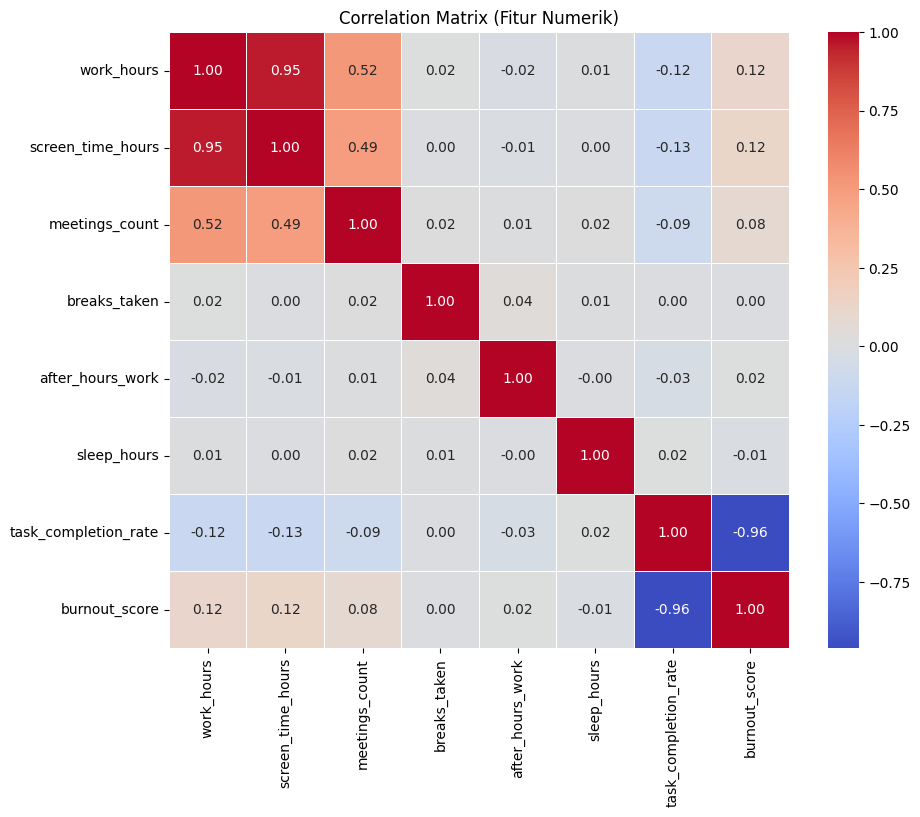

In [ ]:
# ============================================================================
# CELL 4.1: Exploratory Data Analysis (EDA) - Correlation Matrix
# ============================================================================

# Memisahkan kolom numerik secara otomatis saja untuk visualisasi agar tidak error
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# 1. Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: Who affects Burnout Score?')
plt.show()

### Analisis Correlation Matrix

**1. Faktor Dominan terhadap Burnout Score**
Terdapat korelasi negatif yang sangat kuat antara `task_completion_rate` 
dan `burnout_score` sebesar **-0.96**. Ini mengindikasikan bahwa semakin 
rendah tingkat penyelesaian tugas seorang karyawan, semakin tinggi skor 
burnout yang dialaminya. Variabel ini menjadi prediktor tunggal terkuat 
dalam dataset.

**2. Faktor Lain Tidak Signifikan**
Faktor-faktor seperti `work_hours` (0.12), `screen_time_hours` (0.12), 
`meetings_count` (0.08), `after_hours_work` (0.02), `sleep_hours` (-0.01), 
dan `breaks_taken` (0.00) menunjukkan korelasi yang sangat lemah terhadap 
`burnout_score`. Hal ini mengindikasikan bahwa variabel-variabel tersebut 
secara linear tidak cukup berkontribusi dalam memprediksi tingkat burnout 
pada dataset ini.

**3. Multikolinearitas antar Fitur**
Ditemukan multikolinearitas yang tinggi antara `work_hours` dan 
`screen_time_hours` dengan nilai korelasi sebesar **0.95**, serta antara 
`work_hours` dan `meetings_count` sebesar **0.52**. Kondisi ini menunjukkan 
bahwa ketiga variabel tersebut cenderung bergerak bersamaan, sehingga 
menyertakan ketiganya sekaligus dalam model berisiko menyebabkan redundansi 
informasi yang dapat mengganggu performa model, khususnya pada Multiple 
Linear Regression.

**4. Catatan Dataset**
Pola korelasi yang ditemukan — di mana satu variabel (`task_completion_rate`) 
mendominasi hampir seluruh varians target — mengindikasikan bahwa dataset 
ini bersifat sintetis. `burnout_score` kemungkinan besar di-generate secara 
matematis dengan `task_completion_rate` sebagai variabel utama, sehingga 
hubungan antar variabel tidak sepenuhnya mencerminkan dinamika burnout di 
dunia nyata.


--- HISTOGRAM FITUR NUMERIK & BURNOUT RISK ---


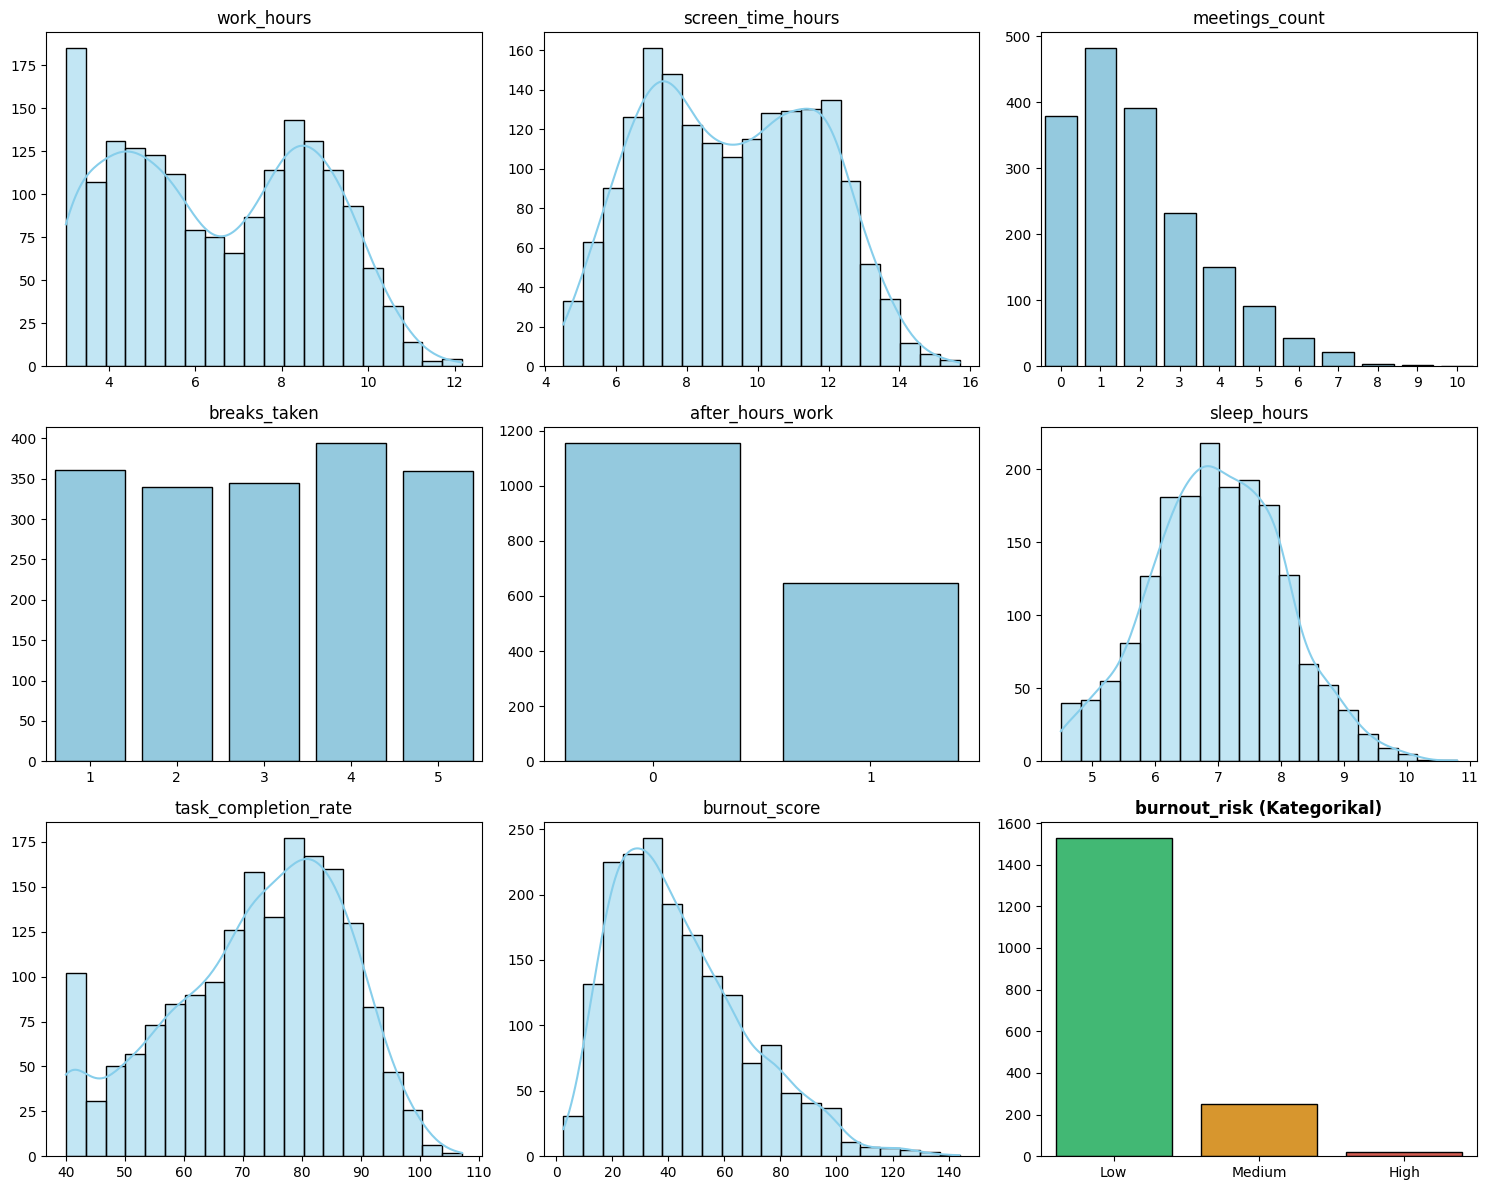

In [6]:
# ============================================================================
# CELL 4.2: Exploratory Data Analysis (EDA) - Histogram
# ============================================================================

# 2. Histogram (Distribusi Data) - Format Grid 3x3
print("\n--- HISTOGRAM FITUR NUMERIK & BURNOUT RISK ---")
# Menyiapkan kanvas 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) 
axes = axes.flatten() # Meratakan array axes agar mudah di-loop

# A. Menggambar Fitur Numerik
for i, col in enumerate(num_cols):
    # Penyesuaian agar fitur dengan sedikit nilai unik (seperti rapat) tetap rapi
    if len(df[col].unique()) <= 15:
        sns.countplot(x=df[col], color='skyblue', edgecolor='black', ax=axes[i])
    else:
        sns.histplot(df[col], bins=20, color='skyblue', edgecolor='black', kde=True, ax=axes[i])
    
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# B. Menambahkan 'burnout_risk' di grid kosong pertama setelah numerik
index_selanjutnya = i + 1

# --- KUSTOMISASI WARNA DI SINI ---
# Gunakan kode warna Hex atau nama warna standar bahasa Inggris
warna_kustom = ['#2ecc71', '#f39c12', '#e74c3c'] # Hijau (Low), Oranye (Medium), Merah (High)

# Menggunakan urutan (order) agar grafiknya rapi dari Low ke High
sns.countplot(
    x=df['burnout_risk'], 
    order=['Low', 'Medium', 'High'], 
    palette=warna_kustom, # <-- Parameter palette diubah memanggil variabel di atas
    edgecolor='black', 
    ax=axes[index_selanjutnya]
)

axes[index_selanjutnya].set_title('burnout_risk (Kategorikal)', fontsize=12, fontweight='bold')
axes[index_selanjutnya].set_xlabel('')
axes[index_selanjutnya].set_ylabel('')

# C. Menghapus kotak grid yang benar-benar kosong
for j in range(index_selanjutnya + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Di sini kita menyadari bahwa jumlah kategori 'low' berjumlah jauh lebih banyak daripada kategori 'medium' & 'high'. Artinya untuk klasifikasi, data ini tidak seimbang. Tentunya tujuannya adalah prediksi regresi, kita tidak harus mempedulikan ini


--- BOXPLOT FITUR NUMERIK ---


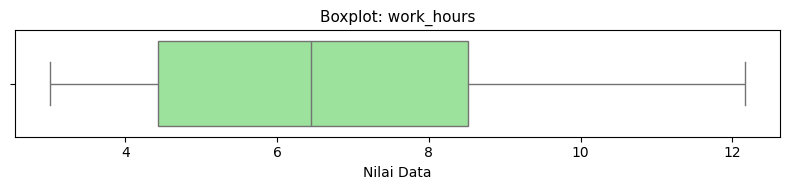

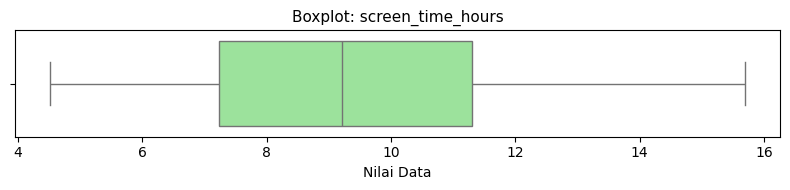

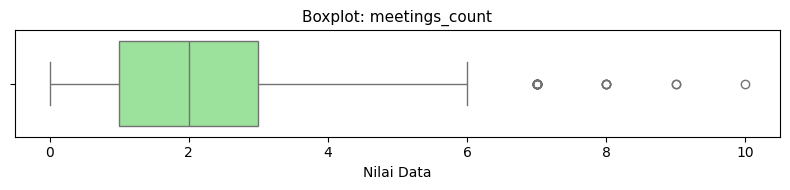

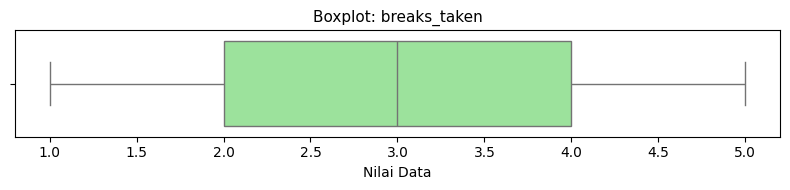

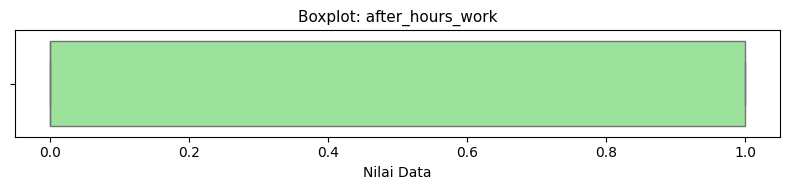

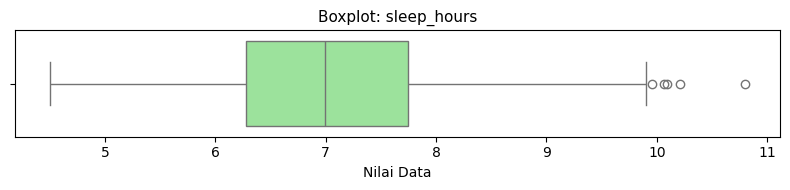

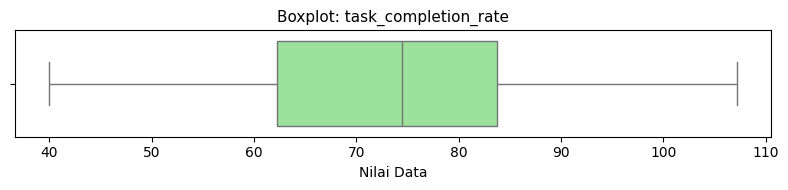

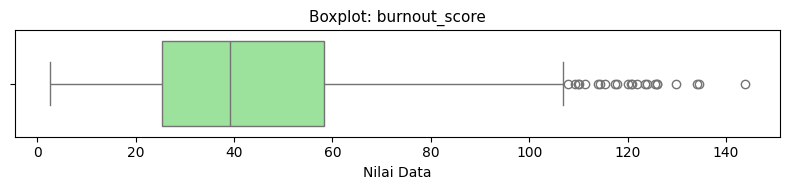

In [7]:
# ============================================================================
# CELL 4.3: Exploratory Data Analysis (EDA) - Boxplot
# ============================================================================

# 3. Boxplot - Horizontal
print("\n--- BOXPLOT FITUR NUMERIK ---")
for col in num_cols:
    # Ukuran kanvas (8, 2) agar lebih ramping
    plt.figure(figsize=(8, 2)) 
    sns.boxplot(x=df[col], orient="h", color='lightgreen')
    plt.title(f"Boxplot: {col}", fontsize=11)
    plt.xlabel("Nilai Data", fontsize=10)
    plt.tight_layout()
    plt.show()

- Terdapat data pencilan (outlier) pada **burnout_score**, **sleep_hours** dan **meetings_count**
- Namun, untuk **sleep_hours** dan **meetings_count** kita tidak perlu khawatir, tidak perlu mengatasinya karena akan kedua fitur ini akan dilaukan ***Feature Engineering*** untuk membuat fitur baru yang bernama **stress_score**. Nanti kalau di **stress_score** nya ada outlier kita atasi di situ (setelah ***Feature Engineering***)
- ***burnout_score*** juga penting, outliernya akan bermasalah pada algoritmanya nanti seperti Regresi Linear yang melibatkan Y juga ke dalam perhitungan dan perkalian sehingga kalau outlier-nya tidak ditangani maka akan berlipat ganda

In [8]:
# ============================================================================
# CELL 5: Data Cleaning (Drop Dupes & Irrelevant Columns)
# ============================================================================

# Catat baris sebelum dihapus
baris_sebelum_dupe = df.shape[0]

# Cek dan buang duplikat
print(f"Jumlah duplikat: {df.duplicated().sum()}")
df = df.drop_duplicates(keep='first')

# Catat baris setelah dan tampilkan laporannya
baris_setelah_dupe = df.shape[0]
print(f"Total baris sebelum drop dupes: {baris_sebelum_dupe}")
print(f"Total baris setelah drop dupes: {baris_setelah_dupe}")
print(f"Baris dihapus: {baris_sebelum_dupe - baris_setelah_dupe}\n")

# Cek Missing Value (Hanya mencatat, belum diisi untuk mencegah Data Leakage)
print("--- CEK MISSING VALUES ---")
print(df.isnull().sum())

# Drop kolom yang tidak mencerminkan perilaku individu
# (Catatan: user_id sudah di-drop di CELL 1)
# task_completion_rate lebih ke metrik performa perusahaan, bu individu dari karakter
# juga secara psikologi, this adalah hasil burnout tersebut, bukan penyebabnya
df = df.drop(columns=['task_completion_rate'])
print("\n=========================================")
print(" KOLOM 'task_completion_rate' TELAH DIHAPUS.")
print("=========================================")

print("\n--- TAMPILAN 10 DATA PERTAMA ---")
display(df.head(10))

Jumlah duplikat: 0
Total baris sebelum drop dupes: 1800
Total baris setelah drop dupes: 1800
Baris dihapus: 0

--- CEK MISSING VALUES ---
day_type                0
work_hours              0
screen_time_hours       0
meetings_count          0
breaks_taken            0
after_hours_work        0
sleep_hours             0
task_completion_rate    0
burnout_score           0
burnout_risk            0
dtype: int64

 KOLOM 'task_completion_rate' TELAH DIHAPUS.

--- TAMPILAN 10 DATA PERTAMA ---


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,burnout_score,burnout_risk
0,Weekday,9.59,11.86,4,2,0,7.55,19.17,Low
1,Weekend,7.38,10.33,4,1,0,6.69,29.70,Low
2,Weekend,6.31,8.92,1,2,0,8.87,32.93,Low
3,Weekday,8.34,10.70,4,1,1,8.13,45.47,Low
4,Weekend,6.97,9.83,1,2,0,5.85,51.61,Low
5,Weekday,7.24,9.09,1,4,0,7.53,54.16,Low
6,Weekday,8.09,11.64,6,3,1,5.04,68.83,Low
7,Weekday,7.15,9.98,3,4,0,5.89,78.89,Medium
8,Weekday,8.72,11.80,1,2,0,6.19,84.39,Medium
9,Weekend,5.93,9.17,0,4,0,7.88,83.86,Medium


In [9]:
# ============================================================================
# CELL 6: Feature Engineering & Label Encoding
# ============================================================================

# 1. Feature Engineering: Membuat 'stress_score' (Indeks beban kognitif Eekstra, dihitung berdasarkan logika heuristik)
df['stress_score'] = np.maximum(0, df['work_hours'] - 8) + df['after_hours_work'] + (df['meetings_count'] * 0.5)
print("=========================================")
print(" FITUR 'stress_score' BERHASIL DIBUAT.")
print("=========================================")

# 2. Label Encoding (Binary & Ordinal)
df['day_type'] = df['day_type'].map({'Weekday': 0, 'Weekend': 1})
df['burnout_risk'] = df['burnout_risk'].map({'Low': 0, 'Medium': 1, 'High': 2})
print("\n=========================================")
print(" LABEL ENCODING PADA 'day_type' DAN 'burnout_risk' SELESAI.")
print("=========================================")

# Cek hasil akhir sebelum data dipecah
df.head(10)

 FITUR 'stress_score' BERHASIL DIBUAT.

 LABEL ENCODING PADA 'day_type' DAN 'burnout_risk' SELESAI.


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,burnout_score,burnout_risk,stress_score
0,0,9.59,11.86,4,2,0,7.55,19.17,0,3.59
1,1,7.38,10.33,4,1,0,6.69,29.70,0,2.00
2,1,6.31,8.92,1,2,0,8.87,32.93,0,0.50
3,0,8.34,10.70,4,1,1,8.13,45.47,0,3.34
4,1,6.97,9.83,1,2,0,5.85,51.61,0,0.50
5,0,7.24,9.09,1,4,0,7.53,54.16,0,0.50
6,0,8.09,11.64,6,3,1,5.04,68.83,0,4.09
7,0,7.15,9.98,3,4,0,5.89,78.89,1,1.50
8,0,8.72,11.80,1,2,0,6.19,84.39,1,1.22
9,1,5.93,9.17,0,4,0,7.88,83.86,1,0.00


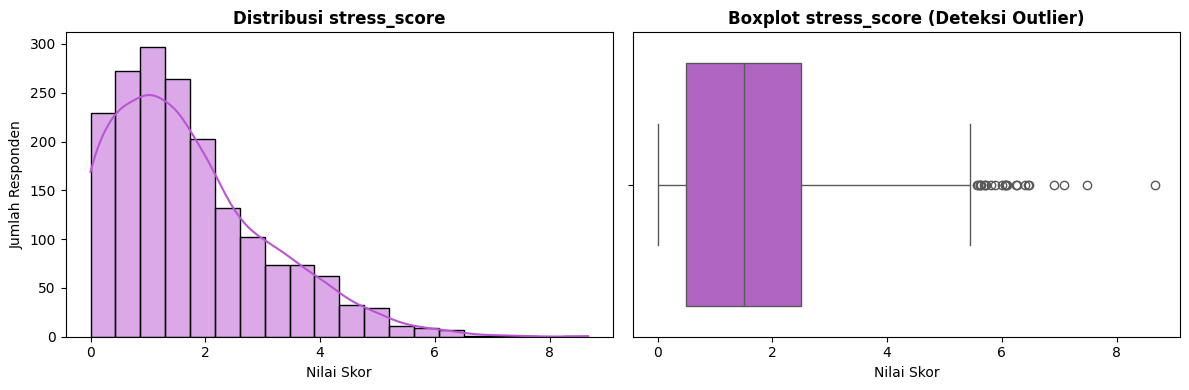

INFO: Berdasarkan hitungan IQR, nilai stress_score di atas 5.50 dan di bawah -2.50 dianggap sebagai OUTLIER.


In [10]:
# ============================================================================
# CELL 6.5: Visualize New Feature (stress_score) Distribution & Outlier
# ============================================================================

# Menyiapkan kanvas dengan 1 baris dan 2 kolom (Kiri-Kanan)
plt.figure(figsize=(12, 4))

# 1. HISTOGRAM
plt.subplot(1, 2, 1)
sns.histplot(df['stress_score'], kde=True, color='mediumorchid', edgecolor='black', bins=20)
plt.title('Distribusi stress_score', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Skor')
plt.ylabel('Jumlah Responden')

# 2. BOXPLOT
plt.subplot(1, 2, 2)
sns.boxplot(x=df['stress_score'], color='mediumorchid')
plt.title('Boxplot stress_score (Deteksi Outlier)', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Skor')

# Menampilkan grafik dengan rapi
plt.tight_layout()
plt.show()

# Cek persisnya seberapa jauh batas wajarnya
Q1 = df['stress_score'].quantile(0.25)
Q3 = df['stress_score'].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR
batas_bawah = Q1 - 1.5 * IQR

print(f"INFO: Berdasarkan hitungan IQR, nilai stress_score di atas {batas_atas:.2f} dan di bawah {batas_bawah:.2f} dianggap sebagai OUTLIER.")

- Di sini kita menyadari adanya sekumpulan outlier pada fitur baru yang bernama **stress_score** sehingga perlu ditangani

In [11]:
# ============================================================================
# CELL 7: Train/Test Split (Preventing Data Leakage Before Norm/Standard/Transform)
# ============================================================================
from sklearn.model_selection import train_test_split

# Fitur X yang disepakati untuk Regresi
fitur_x = ['day_type', 'screen_time_hours', 'breaks_taken', 'sleep_hours', 'stress_score']

X = df[fitur_x]
# Target Y adalah burnout_score (Angka asli)
y = df['burnout_score'] 

# Pemisahan 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah Data Training: {X_train.shape[0]} baris")
print(f"Jumlah Data Testing: {X_test.shape[0]} baris")

Jumlah Data Training: 1440 baris
Jumlah Data Testing: 360 baris


In [12]:
# ============================================================================
# CELL 8: Handle Missing Values (Median Imputation)
# ============================================================================
from sklearn.impute import SimpleImputer

# Inisialisasi pengisi nilai kosong menggunakan Median
handling_missing = 'median'
imputer = SimpleImputer(strategy=handling_missing)
print("=========================================")
print(f" HANDLE MISSING VALUE MENGGUNAKAN {handling_missing} SELESAI.")
print("=========================================")

# PENTING: Fit (belajar median) HANYA dari X_train, lalu isi ke X_train dan X_test
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# Cek Missing Value Kembali
print("\n--- CEK MISSING VALUES SETELAH HANDLING ---")
print(X_train_imputed.isnull().sum())

# --- TAMBAHAN: Menampilkan Dataframe SEBELUM Normalisasi ---
print("\n--- TAMPILAN 10 DATA PERTAMA (SEBELUM NORMALISASI) ---")
display(X_train_imputed.head(10))

 HANDLE MISSING VALUE MENGGUNAKAN median SELESAI.

--- CEK MISSING VALUES SETELAH HANDLING ---
day_type             0
screen_time_hours    0
breaks_taken         0
sleep_hours          0
stress_score         0
dtype: int64

--- TAMPILAN 10 DATA PERTAMA (SEBELUM NORMALISASI) ---


,day_type,screen_time_hours,breaks_taken,sleep_hours,stress_score
832,1.0,7.81,3.0,5.61,1.00
836,1.0,9.00,1.0,7.42,0.00
1103,0.0,12.54,4.0,9.00,4.27
859,0.0,12.28,4.0,6.84,2.60
567,0.0,12.92,3.0,5.83,3.04
175,0.0,11.61,5.0,8.91,4.36
1461,1.0,5.09,4.0,7.82,2.50
677,0.0,10.47,4.0,7.38,2.09
1394,0.0,8.89,3.0,6.74,0.50
334,1.0,6.83,5.0,5.85,2.50


In [13]:
# ============================================================================
# CELL 8.5: Ekstrak Batas Rule-Based Otomatis dari Dataset Asli
# ============================================================================

# 1. Cari nilai paling minimum dari kategori Medium (1) dan High (2) di dataset asli (df)
# Karena di CELL 6 kita sudah melakukan: Low = 0, Medium = 1, High = 2
batas_min_medium = df[df['burnout_risk'] == 1]['burnout_score'].min()
batas_min_high = df[df['burnout_risk'] == 2]['burnout_score'].min()

print("==================================================")
print(" BATAS RULE-BASED OTOMATIS BERHASIL DITEMUKAN")
print("==================================================")
print(f"Batas masuk Medium : {batas_min_medium}")
print(f"Batas masuk High   : {batas_min_high}")

# 2. Fungsi dinamis menggunakan variabel di atas (Disimpan untuk Cell 13 & 14 nanti)
def klasifikasi_burnout_dinamis(skor):
    if skor < batas_min_medium: 
        return 'Low'
    elif skor < batas_min_high:
        return 'Medium'
    else:
        return 'High'

 BATAS RULE-BASED OTOMATIS BERHASIL DITEMUKAN
Batas masuk Medium : 70.01
Batas masuk High   : 110.22


In [14]:
# ============================================================================
# CELL 9: Stitching Dataset to Export the Cleaned Dataset
# ============================================================================

# 1. Gabungkan X_train dan X_test yang sudah bersih dari missing value
df_full_features = pd.concat([X_train_imputed, X_test_imputed])

# 2. Gabungkan juga y_train dan y_test (Target) agar tabelnya lengkap
df_full_target = pd.concat([y_train, y_test])

# 3. Satukan fitur dan target ke dalam satu variabel baru yang utuh
df_clean = df_full_features.copy()
df_clean['burnout_score'] = df_full_target

# 4. KUNCI UTAMA: Urutkan berdasarkan Index agar posisinya kembali ke urutan Excel asli!
df_clean = df_clean.sort_index()

# 5. CANGKOK KOLOM ASLI: Copy langsung kategori risiko dari dataset df mentah
# Menggunakan .loc untuk memastikan nomor barisnya benar-benar cocok dan tidak tertukar
df_clean['burnout_risk'] = df.loc[df_clean.index, 'burnout_risk']

print("=========================================")
print(" BERHASIL MEMBUAT CLEAN DATASET")
print("=========================================")
print(f"\nTotal baris sekarang: {df_clean.shape[0]}")
print("\n--- TAMPILAN 10 DATA PERTAMA ---")
display(df_clean.head(10))

# (Opsional) Jika kamu ingin mengekspornya langsung ke CSV:
nama_file_ekspor_df_clean = 'dataset_clean_rf.csv'
df_clean.to_csv(nama_file_ekspor_df_clean, index=True, index_label='index')
print("\n#########################################")
print(f" CLEAN DATASET DIEKSPOR DENGAN NAMA: {nama_file_ekspor_df_clean}")
print("#########################################")

 BERHASIL MEMBUAT CLEAN DATASET

Total baris sekarang: 1800

--- TAMPILAN 10 DATA PERTAMA ---


,day_type,screen_time_hours,breaks_taken,sleep_hours,stress_score,burnout_score,burnout_risk
0,0.0,11.86,2.0,7.55,3.59,19.17,0
1,1.0,10.33,1.0,6.69,2.00,29.70,0
2,1.0,8.92,2.0,8.87,0.50,32.93,0
3,0.0,10.70,1.0,8.13,3.34,45.47,0
4,1.0,9.83,2.0,5.85,0.50,51.61,0
5,0.0,9.09,4.0,7.53,0.50,54.16,0
6,0.0,11.64,3.0,5.04,4.09,68.83,0
7,0.0,9.98,4.0,5.89,1.50,78.89,1
8,0.0,11.80,2.0,6.19,1.22,84.39,1
9,1.0,9.17,4.0,7.88,0.00,83.86,1



#########################################
 CLEAN DATASET DIEKSPOR DENGAN NAMA: dataset_clean_rf.csv
#########################################


In [15]:
# ============================================================================
# CELL 10: Check Outliers (BEFORE Transform & Normalization)
# ============================================================================

# Kolom numerik yang akan kita cek outliernya (day_type tidak termasuk, karena asalnya dari label)
kolom_numerik = ['screen_time_hours', 'breaks_taken', 'sleep_hours', 'stress_score']

# --- Menghitung Outlier dengan Metode IQR ---
def hitung_total_outlier(df, kolom_list):
    total_outlier = 0
    for col in kolom_list:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        batas_bawah = Q1 - 1.5 * IQR
        batas_atas = Q3 + 1.5 * IQR
        # Hitung baris yang nilainya di luar batas kewajaran
        outlier_col = ((df[col] < batas_bawah) | (df[col] > batas_atas)).sum()
        total_outlier += outlier_col
    return total_outlier

# Hitung dan tampilkan outlier  (Sebelum transform & normalisasi)
outlier_sebelum = hitung_total_outlier(X_train_imputed, kolom_numerik)

print("==================================================")
print(f" JUMLAH OUTLIER SEBELUM LOG & Z-SCORE : {outlier_sebelum}")
print("==================================================")
print("*Catatan: Angka ini didapat dari perhitungan batas IQR (Q1 dan Q3).")

 JUMLAH OUTLIER SEBELUM LOG & Z-SCORE : 21
*Catatan: Angka ini didapat dari perhitungan batas IQR (Q1 dan Q3).


In [16]:
# # ============================================================================
# # CELL 10.1: WINSORIZATION TO HANDLE THE REST OF OUTLIERS (Optional, Comment to turn it off)
# # ============================================================================

# kolom_numerik = ['screen_time_hours', 'breaks_taken', 'sleep_hours', 'stress_score']

# print("--- PROSES WINSORIZATION DIMULAI ---")

# for col in kolom_numerik:
#     # PENTING: Batas IQR Dihitung HANYA dari Data Training untuk mencegah kebocoran data
#     Q1 = X_train_imputed[col].quantile(0.25)
#     Q3 = X_train_imputed[col].quantile(0.75)
#     IQR = Q3 - Q1
#     batas_bawah = Q1 - 1.5 * IQR
#     batas_atas = Q3 + 1.5 * IQR
    
#     # Proses pemotongan (Capping) menggunakan fungsi .clip() dari Pandas
#     # Semua angka di bawah batas_bawah akan diubah jadi batas_bawah
#     # Semua angka di atas batas_atas akan diubah jadi batas_atas
#     X_train_imputed[col] = X_train_imputed[col].clip(lower=batas_bawah, upper=batas_atas)
#     X_test_imputed[col] = X_test_imputed[col].clip(lower=batas_bawah, upper=batas_atas)
    
#     print(f"[{col}] Capping selesai. Batas rentang diubah: {batas_bawah:.2f} s/d {batas_atas:.2f}")

# print("\n==================================================")
# print(" SISA OUTLIER SUDAH DIJINAKKAN DENGAN WINSORIZATION")
# print("==================================================")

# # Cek kembali jumlah outlier menggunakan fungsi dari Cell 10
# outlier_setelah_winsor = hitung_total_outlier(X_train_imputed, kolom_numerik)
# print(f"\nJUMLAH OUTLIER SETELAH WINSORIZATION: {outlier_setelah_winsor} (seharusnya 0)")

In [17]:
# ============================================================================
# CELL 10.2: Logarithm Transform (Log1p) for Feature X (Optional, Comment to turn it off, check Cell 15 (2B) if off)
# ============================================================================

# Terapkan logaritma pada data training dan testing
X_train_imputed[kolom_numerik] = np.log1p(X_train_imputed[kolom_numerik])
X_test_imputed[kolom_numerik] = np.log1p(X_test_imputed[kolom_numerik]) # Walaupun kita tidak akan memakai bagian ini Random Forest... kita biatkan saja karena kode awalnya memang template

print("==================================================")
print(" TRANSFORMASI LOGARITMIK (LOG1P) PADA FITUR X SELESAI")
print("==================================================")

# --- Menampilkan Dataframe yang sudah di-Transform ---
print("\n--- TAMPILAN 10 DATA PERTAMA SETELAH LOG & SEBELUM Z-SCORE ---")
display(X_train_imputed.head(10))

# Hitung dan tampilkan outlier SETELAH semua proses (Fungsi terbaca dari Cell 10)
outlier_setelah = hitung_total_outlier(X_train_imputed, kolom_numerik)

print("\n==================================================")
print(f" JUMLAH OUTLIER SETELAH LOG & SEBELUM Z-SCORE : {outlier_setelah}")
print("==================================================")

 TRANSFORMASI LOGARITMIK (LOG1P) PADA FITUR X SELESAI

--- TAMPILAN 10 DATA PERTAMA SETELAH LOG & SEBELUM Z-SCORE ---


,day_type,screen_time_hours,breaks_taken,sleep_hours,stress_score
832,1.0,2.175887,1.386294,1.888584,0.693147
836,1.0,2.302585,0.693147,2.130610,0.000000
1103,0.0,2.605648,1.609438,2.302585,1.662030
859,0.0,2.586259,1.609438,2.059239,1.280934
567,0.0,2.633327,1.386294,1.921325,1.396245
175,0.0,2.534490,1.791759,2.293544,1.678964
1461,1.0,1.806648,1.609438,2.177022,1.252763
677,0.0,2.439735,1.609438,2.125848,1.128171
1394,0.0,2.291524,1.386294,2.046402,0.405465
334,1.0,2.057963,1.791759,1.924249,1.252763



 JUMLAH OUTLIER SETELAH LOG & SEBELUM Z-SCORE : 12


In [18]:
# ============================================================================
# CELL 11: Normalization (Z-Score)
# ============================================================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# PENTING: Fit scaler HANYA pada X_train!
X_train_imputed[kolom_numerik] = scaler.fit_transform(X_train_imputed[kolom_numerik])
X_test_imputed[kolom_numerik] = scaler.transform(X_test_imputed[kolom_numerik])

print("==================================================")
print(" NORMALISASI Z-SCORE BERHASIL DITERAPKAN.")
print("==================================================")

# --- Menampilkan Dataframe yang sudah diproses penuh ---
print("\n--- TAMPILAN 10 DATA PERTAMA SETELAH LOG & Z-SCORE ---")
display(X_train_imputed.head(10))

# Hitung dan tampilkan outlier SETELAH semua proses (Fungsi terbaca dari Cell 10)
outlier_setelah = hitung_total_outlier(X_train_imputed, kolom_numerik)

print("\n==================================================")
print(f" JUMLAH OUTLIER SETELAH LOG & Z-SCORE : {outlier_setelah}")
print("==================================================")

 NORMALISASI Z-SCORE BERHASIL DITERAPKAN.

--- TAMPILAN 10 DATA PERTAMA SETELAH LOG & Z-SCORE ---


,day_type,screen_time_hours,breaks_taken,sleep_hours,stress_score
832,1.0,-0.506852,0.157776,-1.374960,-0.363075
836,1.0,0.013955,-1.613450,0.434701,-1.730234
1103,0.0,1.259734,0.727984,1.720583,1.547945
859,0.0,1.180033,0.727984,-0.098949,0.796273
567,0.0,1.373509,0.157776,-1.130151,1.023711
175,0.0,0.967230,1.193877,1.652984,1.581345
1461,1.0,-2.024656,0.727984,0.781730,0.740709
677,0.0,0.577726,0.727984,0.399096,0.494964
1394,0.0,-0.031512,0.157776,-0.194934,-0.930497
334,1.0,-0.991597,1.193877,-1.108288,0.740709



 JUMLAH OUTLIER SETELAH LOG & Z-SCORE : 12


In [19]:
# ============================================================================
# CELL 12: Hyperparameter Tuning (GridSearchCV), Begin Training, & Evaluation for Random Forest
# ============================================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score

print("--- MEMULAI GRID SEARCH (Mohon tunggu, komputasi sedang berjalan, ini akan memakan waktu lama...) ---")

# 1. Siapkan Model Dasar
rf_dasar = RandomForestRegressor(random_state=42) # Random state 42 agar tiap kali training hasilnya akan tetap sama

# 2. Tentukan "Menu" Grid (Kombinasi parameter yang mau dites)
# Jangan terlalu banyak dulu agar tidak menunggu berjam-jam!
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Inisialisasi GridSearchCV
# cv=3 (membagi data train jadi 3 bagian untuk validasi silang)
# n_jobs=-1 (pakai seluruh tenaga prosesor komputer)
# verbose=1 (menampilkan teks progres agar kamu tahu dia tidak nge-hang)
grid_search = GridSearchCV(estimator=rf_dasar, param_grid=param_grid, 
                           cv=3, n_jobs=-1, scoring='r2', verbose=1)

# 4. Latih dan Cari Kombinasi Terbaik (Bisa memakan waktu beberapa saat!)
grid_search.fit(X_train_imputed, y_train)

# 5. AMBIL MODEL TERBAIK HASIL GRID SEARCH
model_rf = grid_search.best_estimator_

print("\n==================================================")
print(" SELESAI! MODEL TERBAIK RANDOM FOREST REGRESSOR DITEMUKAN")
print("==================================================")
print("Hyperparameter Terbaik:", grid_search.best_params_)

# 6. Lakukan Prediksi pada Data Ujian
y_pred = model_rf.predict(X_test_imputed)

# 7. Evaluasi Model Terbaik
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n==================================================")
print(" HASIL EVALUASI MODEL (RANDOM FOREST + GRID SEARCH)")
print("==================================================")
print(f"R-Squared (Akurasi Varians) : {r2:.4f} (Mendekati 1.0 semakin baik)")
print(f"MAPE (Persentase Meleset)   : {mape:.2%} (Mendekati 0% semakin baik)")
print(f"RMSE (Rata-rata Error Poin) : {rmse:.2f} poin")
print("==================================================")

# 8. Tampilkan Feature Importances
print("\n--- TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCES) ---")
importances = model_rf.feature_importances_
fitur_penting = pd.DataFrame({'Fitur': X_train_imputed.columns, 'Pentingnya (%)': importances * 100})
fitur_penting = fitur_penting.sort_values(by='Pentingnya (%)', ascending=False)

for index, row in fitur_penting.iterrows():
    print(f"{row['Fitur']:<20} : {row['Pentingnya (%)']:.2f}%")

--- MEMULAI GRID SEARCH (Mohon tunggu, komputasi sedang berjalan, ini akan memakan waktu lama...) ---
Fitting 3 folds for each of 108 candidates, totalling 324 fits

 SELESAI! MODEL TERBAIK RANDOM FOREST REGRESSOR DITEMUKAN
Hyperparameter Terbaik: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

 HASIL EVALUASI MODEL (RANDOM FOREST + GRID SEARCH)
R-Squared (Akurasi Varians) : -0.0010 (Mendekati 1.0 semakin baik)
MAPE (Persentase Meleset)   : 68.69% (Mendekati 0% semakin baik)
RMSE (Rata-rata Error Poin) : 23.76 poin

--- TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCES) ---
screen_time_hours    : 39.08%
sleep_hours          : 31.81%
stress_score         : 19.42%
breaks_taken         : 7.62%
day_type             : 2.08%


In [20]:
# ============================================================================
# CELL 13: Save the Best Model & Scaler (Joblib)
# ============================================================================
import joblib

# 1. Tentukan nama file dalam variabel agar fleksibel
nama_file_model = 'model_burnout_rf1.pkl'
nama_file_scaler = 'scaler_burnout_rf1.pkl'

# 2. Simpan Model
joblib.dump(model_rf, nama_file_model)
print("#########################################")
print(f" MODEL BERHASIL DISIMPAN DENGAN NAMA : {nama_file_model}")

# 3. Simpan Scaler - Ini penting karena kedua model bekerja sebagai satu kesatuan yang tidak bisa...
# dipisahkan saat model nanti di- deploy (misalnya dijadikan website atau aplikasi) 
joblib.dump(scaler, nama_file_scaler)
print(f" SCALER BERHASIL DISIMPAN DENGAN NAMA : {nama_file_scaler}")
print("#########################################")

# --- Cara memanggilnya nanti di file Python/Aplikasi lain ---
# model_loaded = joblib.load(nama_file_model)
# scaler_loaded = joblib.load(nama_file_scaler)

#########################################
 MODEL BERHASIL DISIMPAN DENGAN NAMA : model_burnout_rf1.pkl
 SCALER BERHASIL DISIMPAN DENGAN NAMA : scaler_burnout_rf1.pkl
#########################################


In [21]:
# ============================================================================
# CELL 14: Export Result Predict vs Actual to CSV (Scaled)
# ============================================================================

# 1. Kita gunakan X_test_imputed karena ini berisi angka yang SUDAH di-Z-Score (Scaled)
df_scaled = X_test_imputed.copy()

# 2. Tambahkan kolom Skor Aktual
df_scaled['burnout_score_actual'] = y_test.values

# 3. Tambahkan kolom Skor Prediksi (y_pred berasal dari CELL 11)
df_scaled['burnout_score_predict'] = np.round(y_pred, 2)

# 4. Tambahkan kolom Error (Seberapa jauh melesetnya, error_diff)
df_scaled['error_diff'] = np.abs(df_scaled['burnout_score_actual'] - df_scaled['burnout_score_predict'])
df_scaled['error_diff'] = np.round(df_scaled['error_diff'], 2)

# --- TAMBAHAN: KLASIFIKASI BURNOUT AKTUAL VS PREDIKSI ---
# Menggunakan fungsi dinamis dari CELL 8.5 (Min_max Rule-Based)
# Karena ini file SCALED, setelah diklasifikasi langsung kita map kembali ke angka kesepakatan CELL 6
df_scaled['burnout_risk_actual'] = df_scaled['burnout_score_actual'].apply(klasifikasi_burnout_dinamis).map({'Low': 0, 'Medium': 1, 'High': 2})
df_scaled['burnout_risk_predict'] = df_scaled['burnout_score_predict'].apply(klasifikasi_burnout_dinamis).map({'Low': 0, 'Medium': 1, 'High': 2})

# 5. Urutkan berdasarkan INDEX agar posisinya sama persis dengan Excel asli dan dataset Inverse
df_scaled_sorted = df_scaled.sort_index()

# 6. Ekspor ke file CSV dengan menyertakan Index
nama_file_ekspor_scaled = 'dataset_scaled_predict_rf1.csv'
df_scaled_sorted.to_csv(nama_file_ekspor_scaled, index=True, index_label='index')

print("#########################################")
print(f" PREDICT SCALED DIEKSPOR DENGAN NAMA: '{nama_file_ekspor_scaled}'")
print("#########################################")
print("\n--- 10 DATA PERTAMA HASIL SCALED ---")
display(df_scaled_sorted.head(10))

#########################################
 PREDICT SCALED DIEKSPOR DENGAN NAMA: 'dataset_scaled_predict_rf1.csv'
#########################################

--- 10 DATA PERTAMA HASIL SCALED ---


,day_type,screen_time_hours,breaks_taken,sleep_hours,stress_score,burnout_score_actual,burnout_score_predict,error_diff,burnout_risk_actual,burnout_risk_predict
23,0.0,1.352786,-0.577349,-0.146787,0.974275,19.01,47.93,28.92,0,0
29,1.0,-0.205556,0.157776,0.756254,-0.363075,33.26,45.23,11.97,0,0
30,0.0,1.289982,-1.613450,-1.710417,0.969263,18.66,47.87,29.21,0,0
32,1.0,-1.124984,0.727984,0.982471,-0.363075,26.79,37.82,11.03,0,0
44,0.0,1.600420,1.193877,-1.108288,0.740709,34.90,48.00,13.10,0,0
49,1.0,-0.201222,1.193877,1.500540,-1.730234,54.85,43.65,11.20,0,0
51,0.0,0.268959,-0.577349,-1.086489,0.436663,20.43,45.03,24.60,0,0
59,1.0,-1.997745,-0.577349,-0.351120,-0.930497,54.23,39.59,14.64,0,0
65,1.0,-0.625185,1.193877,-0.204601,-0.930497,31.55,41.91,10.36,0,0
67,0.0,0.230143,-1.613450,0.327372,-1.730234,43.07,37.45,5.62,0,0


In [22]:
# ============================================================================
# CELL 15: Export Result Predict vs Actual to CSV (Inverse)
# ============================================================================

# Nama file ekspor dibungkus dalam variabel agar fleksibel
nama_file_ekspor_inverse = 'dataset_inverse_predict_rf1.csv'

# 1. DUPLIKASI DATA UJIAN (X_test_imputed)
df_inverse = X_test_imputed.copy()

# 2. PROSES INVERSE TRANSFORM NYATA (Hanya pada kolom yang di-scale)
kolom_numerik = ['screen_time_hours', 'breaks_taken', 'sleep_hours', 'stress_score']
# A. Kembalikan dulu dari Z-Score ke bentuk Logaritma
df_inverse[kolom_numerik] = scaler.inverse_transform(df_inverse[kolom_numerik])

# B. KEMBALIKAN FITUR X DARI LOGARITMA KE ANGKA ASLI
# COMMENT BAWAH INI KALAU CELL 10.2 DICOMMENT (NONAKTIF)

df_inverse[kolom_numerik] = np.expm1(df_inverse[kolom_numerik])

# 3. DECODING LABEL KATEGORI
# Mengembalikan angka 0 dan 1 pada day_type menjadi string aslinya
df_inverse['day_type'] = df_inverse['day_type'].round().map({0: 'Weekday', 1: 'Weekend'})

# 4. GABUNGKAN DENGAN TARGET & PREDIKSI
df_inverse['burnout_score_actual'] = y_test.values
df_inverse['burnout_score_predict'] = np.round(y_pred, 2)

# 5. HITUNG SELISIH ERROR (error_diff) MUTLAK
df_inverse['error_diff'] = np.abs(df_inverse['burnout_score_actual'] - df_inverse['burnout_score_predict'])
df_inverse['error_diff'] = np.round(df_inverse['error_diff'], 2)

# --- TAMBAHAN: KLASIFIKASI RISIKO AKTUAL VS PREDIKSI ---
# Menggunakan fungsi dinamis dari CELL 8.5
df_inverse['burnout_risk_actual'] = df_inverse['burnout_score_actual'].apply(klasifikasi_burnout_dinamis)
df_inverse['burnout_risk_predict'] = df_inverse['burnout_score_predict'].apply(klasifikasi_burnout_dinamis)

# 6. ORDER BY INDEKS ASLI (.sort_index)
hasil_inverse_sorted = df_inverse.sort_index()

# 7. EKSPOR KE CSV DENGAN MENAMPILKAN & MEMBERI NAMA KOLOM INDEKS
# Disamakan dengan Cell 14 agar kolom index bernama 'index'
hasil_inverse_sorted.to_csv(nama_file_ekspor_inverse, index=True, index_label='index')

print("#########################################")
print(f" PREDICT INVERSE DIEKSPOR DENGAN NAMA: '{nama_file_ekspor_inverse}'")
print("#########################################")
print("\n--- TAMPILAN 10 DATA PERTAMA HASIL INVERSE (BASELINE) ---")
display(hasil_inverse_sorted.head(10))

#########################################
 PREDICT INVERSE DIEKSPOR DENGAN NAMA: 'dataset_inverse_predict_rf1.csv'
#########################################

--- TAMPILAN 10 DATA PERTAMA HASIL INVERSE (BASELINE) ---


,day_type,screen_time_hours,breaks_taken,sleep_hours,stress_score,burnout_score_actual,burnout_score_predict,error_diff,burnout_risk_actual,burnout_risk_predict
23,Weekday,12.85,2.0,6.79,2.94,19.01,47.93,28.92,Low,Low
29,Weekend,8.48,3.0,7.79,1.00,33.26,45.23,11.97,Low,Low
30,Weekday,12.64,1.0,5.32,2.93,18.66,47.87,29.21,Low,Low
32,Weekend,6.58,4.0,8.06,1.00,26.79,37.82,11.03,Low,Low
44,Weekday,13.71,5.0,5.85,2.50,34.90,48.00,13.10,Low,Low
49,Weekend,8.49,5.0,8.71,0.00,54.85,43.65,11.20,Low,Low
51,Weekday,9.64,2.0,5.87,2.00,20.43,45.03,24.60,Low,Low
59,Weekend,5.13,2.0,6.58,0.50,54.23,39.59,14.64,Low,Low
65,Weekend,7.56,5.0,6.73,0.50,31.55,41.91,10.36,Low,Low
67,Weekday,9.54,1.0,7.30,0.00,43.07,37.45,5.62,Low,Low
